In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


In [2]:

df_original = pd.read_csv("dataset/IO-VNBD/Synchronised V abd S datasets/Categorised IOVNB Dataset/M (Driver B)/S-M.csv",encoding="latin-1")

In [3]:
import geopandas as gpd

df = pd.read_csv("dataset/IO-VNBD/Synchronised V abd S datasets/Categorised IOVNB Dataset/M (Driver B)/S-M.csv", encoding="utf-8", encoding_errors="replace")
df.columns = df.columns.str.strip()
#display(df.head(1))
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["GPS LONGITUDE (degrees)"], df["GPS LATITUDE (degrees)"]),
    crs="EPSG:4326"  # standard lat/lon
)

#display(gdf.head(1))

gdf_web = gdf.to_crs(epsg=3857)

#display(gdf_web.head(1))


In [4]:
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import contextily as ctx

[-176858.39571985 6865091.0353795  -153452.24826617 6887239.08825483]


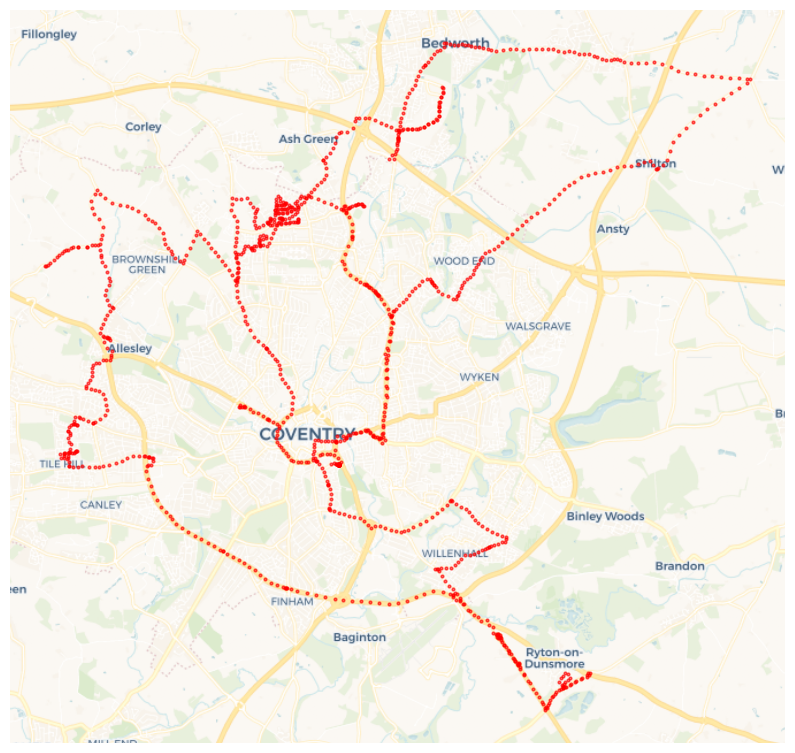

In [5]:
cartodb_url = f"https://basemaps.cartocdn.com/rastertiles/voyager/{{z}}/{{x}}/{{y}}.png?key={os.environ.get('CARTO_API_KEY')}"

# Drop consecutive duplicate GPS points first
gdf_dedup = gdf_web.loc[
    gdf_web.geometry.x.diff().ne(0) | gdf_web.geometry.y.diff().ne(0)
]

# Now downsample the deduplicated trajectory
gdf_plot = gdf_dedup.iloc[::1]

# Sanity check the extent before plotting
print(gdf_plot.total_bounds)

fig, ax = plt.subplots(figsize=(10, 10))

# Points FIRST — sets the correct axis extent
gdf_plot.plot(ax=ax, color="red", markersize=4, alpha=0.6)

# Basemap SECOND — now reads the real extent from the points
ctx.add_basemap(ax, source=cartodb_url)

ax.set_axis_off()
plt.savefig("gps_overlay.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
display(df[::10])

,GPS LATITUDE (degrees),GPS LONGITUDE (degrees),GPS ALTITUDE (m),GPS SPEED (Kmh),GPS ACCURACY (m),GPS ORIENTATION (°),GPS SATELLITES IN RANGE,TIME SINCE START (ms),DATE (YYYY-MO-DD HH-MI-SS_SSS),ACCELEROMETER X (m/s�),ACCELEROMETER Y (m/s�),ACCELEROMETER Z (m/s�),GRAVITY X (m/s�),GRAVITY Y (m/s�),GRAVITY Z (m/s�),GYROSCOPE Yaw (rad/s),GYROSCOPE Pitch (rad/s),GYROSCOPE Roll (rad/s),MAGNETIC FIELD X (μT),MAGNETIC FIELD Y (μT),MAGNETIC FIELD Z (μT),ORIENTATION (Yaw) (°),ORIENTATION (Pitch) (°),ORIENTATION (Roll ) (°)
0,52.402565,-1.503471,144.59,5.84,4.0,92.89,18 / 19,4227,2019-09-07 09:13:29:506,-0.9684,-0.0227,9.9665,0.0089,-0.0009,9.8066,-0.0045,-0.1089,-0.0368,-32.06,-30.37,5.00,312.14,-83.12,-141.80
1000,52.402565,-1.501049,143.57,6.81,3.0,159.65,18 / 19,104227,2019-09-07 09:15:09:506,-3.3409,-4.5415,9.8810,-0.0032,-0.0095,9.8066,-0.0250,-0.6418,0.0484,-31.00,-31.87,15.75,333.93,-86.12,-141.75
2000,52.402600,-1.501101,145.70,6.49,3.0,115.00,18 / 21,204227,2019-09-07 09:16:49:506,2.4412,-4.0286,11.1790,-0.0064,-0.0066,9.8066,-0.0181,-0.5227,0.1179,-13.25,-35.06,-6.37,259.36,-85.89,-155.96
3000,52.403400,-1.508753,144.04,17.42,4.0,231.73,18 / 20,304227,2019-09-07 09:18:29:506,-1.1482,0.7021,10.2502,-0.0176,-0.0016,9.8066,-0.0089,-0.0130,-0.0009,4.44,-32.94,12.88,30.45,-83.58,-174.72
4000,52.412617,-1.515202,142.68,13.57,3.0,359.75,19 / 21,404227,2019-09-07 09:20:09:506,0.1611,0.3393,9.9801,0.0132,0.0064,9.8066,0.0369,-0.0229,0.0884,-13.81,-42.75,-4.06,223.35,-79.55,170.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101000,52.414770,-1.486876,150.25,21.44,3.0,183.44,21 / 21,5678675,2019-09-07 12:01:51:829,-1.1021,-0.1435,9.2987,0.0008,0.0119,9.8066,0.0673,0.1637,0.1475,-27.00,-20.94,30.94,354.16,-82.30,-144.34
102000,52.407696,-1.490815,147.37,0.00,3.0,311.31,21 / 22,5778675,2019-09-07 12:03:31:829,0.8823,0.2562,9.7166,0.0048,-0.0013,9.8066,0.0090,-0.0019,-0.0035,-9.81,-31.56,1.25,278.26,-84.58,-160.03
103000,52.405167,-1.502169,147.43,16.63,3.0,196.64,21 / 22,5878676,2019-09-07 12:05:11:830,-1.1771,-2.5129,10.2852,-0.0106,0.0011,9.8066,-0.0271,-0.1644,0.0131,-15.00,-35.37,18.81,352.09,-83.43,-148.27
104000,52.408684,-1.519528,148.04,16.31,3.0,15.78,21 / 21,5978675,2019-09-07 12:06:51:829,-1.5278,0.3044,9.8989,-0.0189,-0.0018,9.8065,-0.0221,0.0841,0.0011,-26.87,-31.25,-5.12,301.32,-80.94,-129.05


In [11]:
imu_df = df.iloc[:,7::1]
display(imu_df.head(3))

,TIME SINCE START (ms),DATE (YYYY-MO-DD HH-MI-SS_SSS),ACCELEROMETER X (m/s�),ACCELEROMETER Y (m/s�),ACCELEROMETER Z (m/s�),GRAVITY X (m/s�),GRAVITY Y (m/s�),GRAVITY Z (m/s�),GYROSCOPE Yaw (rad/s),GYROSCOPE Pitch (rad/s),GYROSCOPE Roll (rad/s),MAGNETIC FIELD X (μT),MAGNETIC FIELD Y (μT),MAGNETIC FIELD Z (μT),ORIENTATION (Yaw) (°),ORIENTATION (Pitch) (°),ORIENTATION (Roll ) (°)
0,4227,2019-09-07 09:13:29:506,-0.9684,-0.0227,9.9665,0.0089,-0.0009,9.8066,-0.0045,-0.1089,-0.0368,-32.06,-30.37,5.00,312.14,-83.12,-141.80
1,4327,2019-09-07 09:13:29:606,-0.3069,-1.3369,9.9218,-0.0087,0.0096,9.8066,0.0214,-0.1285,-0.0056,-31.75,-30.19,5.38,311.38,-83.06,-142.46
2,4427,2019-09-07 09:13:29:706,-0.0226,-2.0653,10.0332,0.0210,0.0054,9.8066,-0.0368,-0.1373,0.0092,-31.56,-29.94,6.31,311.87,-82.96,-143.69


In [ ]:
initial_pos = (df.iloc[1,1:6:])
print(initial_pos)

imu_df = pd.concat([imu_df,pd.DataFrame({'vel_x':0,'vel_y':0,'vel_z':0},index=imu_df.index)],a)

GPS LONGITUDE (degrees)   -1.503471
GPS ALTITUDE (m)             144.59
GPS SPEED (Kmh)                5.84
GPS ACCURACY (m)                4.0
GPS ORIENTATION (°)           92.89
Name: 1, dtype: object
